### Trabalho Fase 1 do Curso de Pos-Graduacao FIAP IA para Devs
#### Parte 2 - Preparacao inicial de variaveis para algoritmos classificatorios

Fonte de dados escolhida: DATASUS/SISCAN  
Tipo de dados de origem nesta etapa: Parquet

Arquivo utilizado: `SISCAN_MAMOGRAFIA_RJ_2025_tratado.parquet`

---

## Objetivo da Parte 2

Iniciar a preparacao das variaveis para algoritmos classificatorios, separando as colunas em tres listas principais:

- `features_candidates`: colunas de triagem/inicio do atendimento que possuem relacao com indicios ou contexto de cancer de mama;
- `leakage_columns`: colunas que nao sao de triagem, pois dependem de resultado, laudo, BI-RADS, recomendacao, achados finais ou prazos pos-exame;
- `high_cardinality`: colunas com alta cardinalidade, que exigem tratamento especifico antes de entrar em modelos classificatorios.

Nesta etapa ainda nao treinamos modelos. O foco e definir o conjunto inicial de variaveis, evitar vazamento de informacao, criar a target supervisionada, aplicar transformacoes iniciais e exportar as bases finais de treino e teste.

---

## Indice / Sumario da Parte 2

**Item 1 - Imports, leitura da base e criterio de cardinalidade**

- Carregamento das bibliotecas, leitura da base Parquet e definicao do limite para alta cardinalidade.

**Item 2 - Separacao inicial das colunas**

- Definicao de `features_candidates`, `leakage_columns` e `high_cardinality`.

**Item 3 - Validacao das listas**

- Validacao de existencia das colunas, sobreposicao entre listas e features candidatas de alta cardinalidade.

**Item 4 - Base inicial somente com features candidatas**

- Criacao de `df_features_candidates` com o recorte inicial das features permitidas.

**Item 5 - Criacao da variavel alvo para classificacao**

- Criacao de `TARGET_CANCER_MAMA_PROVAVEL` a partir de colunas de resultado/laudo, mantendo essas fontes fora das features.

**Item 6 - Boxplots das features candidatas finais**

- Conversao exploratoria de codigos para valores numericos e avaliacao de outliers por boxplot/IQR.

**Item 7 - Separacao da base em treino e teste**

- Criacao de `X_train`, `X_test`, `y_train` e `y_test` com split estratificado.

**Item 8 - Aplicacao de cap na variavel de idade**

- Criacao de `CO_IDADE_PACIENTE_NUM` e `CO_IDADE_PACIENTE_CAP` usando percentis 1% e 99%.

**Item 9 - Colunas candidatas a One-Hot Encoding**

- Mapeamento das colunas categoricas de baixa cardinalidade, frequencias, significados e classes excluidas do one-hot.

**Item 10 - Aplicacao do One-Hot Encoding nas features candidatas**

- Criacao de `X_train_encoded` e `X_test_encoded`, garantindo o mesmo schema nos dois splits.

**Item 11 - Exportacao dos dados finais em Parquet**

- Exportacao de `x.parquet`, `x_encoded.parquet` e `y.parquet` nas pastas `bases/treino/` e `bases/teste/`.

**Saidas principais da Parte 2**

- `bases/treino/x.parquet`, `bases/treino/x_encoded.parquet`, `bases/treino/y.parquet`
- `bases/teste/x.parquet`, `bases/teste/x_encoded.parquet`, `bases/teste/y.parquet`


#### Item 1 - Imports, leitura da base e criterio de cardinalidade

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)

In [2]:
arquivo_origem = Path('SISCAN_MAMOGRAFIA_RJ_2025_tratado.parquet')
assert arquivo_origem.exists(), f'Arquivo nao encontrado: {arquivo_origem.resolve()}'

dados = pd.read_parquet(arquivo_origem)
dados.shape

(267473, 94)

In [3]:
CARDINALIDADE_ALTA_LIMITE = 20

cardinalidade = dados.nunique(dropna=False).sort_values(ascending=False)
cardinalidade.to_frame('qtd_valores_distintos')

,qtd_valores_distintos
CO_SEQ_SISCAN_MAMOGRAFIA_RESID,267473
CO_IDADE_PACIENTE_NUM,97
CO_IDADE_PACIENTE,97
CO_MUN_RESIDENCIA,92
CO_ANO_MES_RESULTADO,30
CO_ANO_MES_RESULTADO_NUM,30
RESULTADO_MES,30
NU_ANO_MES_COMPETENCIA,12
NU_ANO_MES_COMPETENCIA_NUM,12
COMPETENCIA,12


#### Item 2 - Separacao inicial das colunas

A lista `features_candidates` contem apenas variaveis que podem estar disponiveis na triagem pre-exame/inicio do atendimento e que tem relacao com contexto clinico, risco, historico e indicacao de mamografia.

A lista `quarantine_columns` contem variaveis que parecem descrever avaliacao/achados de mama e linfonodos. Como o objetivo e triagem, essas colunas ficam fora do modelo ate confirmacao formal de que sao coletadas antes da mamografia/laudo.

A lista `leakage_columns` contem variaveis que devem ficar fora do conjunto de features por carregarem informacao posterior ao exame ou ao laudo, como BI-RADS, recomendacoes, achados finais, tempos de resultado e classificacoes radiologicas.

A lista `high_cardinality` e calculada automaticamente com base no limite definido em `CARDINALIDADE_ALTA_LIMITE`. A idade (`CO_IDADE_PACIENTE`) e excecao: apesar de ter muitos valores distintos, ela deve permanecer em `features_candidates` por ser uma variavel numerica/ordinal relevante. Essas colunas nao devem ser usadas diretamente sem estrategia propria de tratamento.

In [4]:
features_candidates = [
    # Perfil e contexto do atendimento
    'CO_IDADE_PACIENTE',
    'SG_SEXO',
    'CO_RACA_COR',
    #'CO_ESCOLARIDADE',

    # Risco e historico mamografico informado na entrada
    'TP_RESP_APRES_RISC_ELEV_CANCER',
    'TP_RESP_ANT_MAMA_EXA_PROF_SAUD',
    'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ',

    # Indicacao e tipo de mamografia solicitada
    'CO_IND_CLINICA',
    'TP_MAMOGRAFIA_RASTREAMENT',
    'CO_TEMPO_MAMO_ANTERIOR_NUM'
]

    
quarantine_columns = [
    # Possiveis achados/avaliacoes de mama e linfonodos. Mantidas fora do cenario pre-exame.
    'TP_MAMA_PELE_ESQ',
    'TP_MAMA_PELE_DIR',
    'TP_MAMA_ESQ',
    'TP_MAMA_DIR',
    'TP_LINFONODO_ESQ',
    'TP_LINFONODO_DIR',
]

leakage_columns = [
    # Resultado, laudo, recomendacao e BI-RADS
    'CO_ANO_RESULTADO',
    'CO_ANO_MES_RESULTADO',
    'TP_RECOMENDACAO_ESQUERDA',
    'TP_RECOMENDACAO_DIREITA',
    'CO_RECOMENDACAO',
    'CO_BIRADS',

    # Indicadores de diagnostico/achados finais
    'NU_CONTROLE_CATEGORIA3',
    'NU_LES_DIAG_CANCER',
    'NU_DIAG_AVAL_QT',
    'NU_REV_MAMOGRAFIA',
    'NU_LES_BIOSPIA_PAAF',
    'NU_NAO_FEZ_CIRURGIAS',
    'NU_FEZ_CIRURGIA_ESQ',
    'NU_FEZ_CIRURGIA_DIR',
    'NU_NODULO_DENS_GORD_ME',
    'NU_NODULO_CALCIFIC_ME',
    'NU_NODULO_DEN_HETEROG_ME',
    'NU_CALC_VASCULARES_ME',
    'NU_CALC_TIPICA_BENIG_ME',
    'NU_LINFON_INTRAMAM_ME',
    'NU_DIS_ARQ_POR_CIR_ME',
    'NU_IMPLANT_SEM_SIN_RUPTU_ME',
    'NU_IMP_COM_SIN_RUPTU_ME',
    'NU_CISTO_OLEOSO_ME',
    'NU_GINECOMASTIA_ME',
    'NU_ECTASIA_DUCTAL_ME',
    'NU_NODULO_DENS_GORD_MD',
    'NU_NODULO_CALCIFIC_MD',
    'NU_NODULO_DEN_HETEROG_MD',
    'NU_CALC_VASCULARES_MD',
    'NU_CALC_TIPICA_BENIG_MD',
    'NU_LINFON_INTRAMAM_MD',
    'NU_DIS_ARQ_POR_CIR_MD',
    'NU_IMPLANT_SEM_SIN_RUPTU_MD',
    'NU_IMP_COM_SIN_RUPTU_MD',
    'NU_CISTO_OLEOSO_MD',
    'NU_GINECOMASTIA_MD',
    'NU_ECTASIA_DUCTAL_MD',
    'CO_TAMANHO_NOD_ESQ',
    'CO_TAMANHO_NOD_DIR',
    'NU_DIAG_ACHADOS',
    'NU_TAMANHO_NODULO',
    'ST_ASSIMETRIA_FOCAL',
    'ST_ASSIMETRIA_DIFUSA',
    'ST_DISTORCAO_FOCAL',
    'ST_AREA_DENSA',
    'ST_ACHADO_BENIGNO',
    'ST_TEM_NODULO',
    'TP_NODULO_CAROCO_MAMA',
    'ST_TEM_MICROCALCIFICACAO',

    # Prazos calculados apos solicitacao/exame/resultado
    'CO_TEMPO_EXAME',
    'CO_INTERVALO_RESULTADO',
    'CO_INTERVALO_SOLICITACAO',
]

high_cardinality_exceptions = [
    # Idade tem muitos valores distintos, mas deve ser tratada como variavel numerica/ordinal.
    'CO_IDADE_PACIENTE',
]

high_cardinality = cardinalidade[cardinalidade > CARDINALIDADE_ALTA_LIMITE].index.tolist()
high_cardinality = [
    coluna for coluna in high_cardinality
    if coluna not in high_cardinality_exceptions
]

features_candidates = [coluna for coluna in features_candidates if coluna in dados.columns]
quarantine_columns = [coluna for coluna in quarantine_columns if coluna in dados.columns]
leakage_columns = [coluna for coluna in leakage_columns if coluna in dados.columns]
high_cardinality = [coluna for coluna in high_cardinality if coluna in dados.columns]

print(f'Features candidatas: {len(features_candidates)}')
print(features_candidates)
print(f'Colunas em quarentena: {len(quarantine_columns)}')
print(quarantine_columns)
print(f'Colunas com vazamento: {len(leakage_columns)}')
print(leakage_columns)
print(f'Alta cardinalidade: {len(high_cardinality)}')
print(high_cardinality)

Features candidatas: 9
['CO_IDADE_PACIENTE', 'SG_SEXO', 'CO_RACA_COR', 'TP_RESP_APRES_RISC_ELEV_CANCER', 'TP_RESP_ANT_MAMA_EXA_PROF_SAUD', 'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ', 'CO_IND_CLINICA', 'TP_MAMOGRAFIA_RASTREAMENT', 'CO_TEMPO_MAMO_ANTERIOR_NUM']
Colunas em quarentena: 6
['TP_MAMA_PELE_ESQ', 'TP_MAMA_PELE_DIR', 'TP_MAMA_ESQ', 'TP_MAMA_DIR', 'TP_LINFONODO_ESQ', 'TP_LINFONODO_DIR']
Colunas com vazamento: 53
['CO_ANO_RESULTADO', 'CO_ANO_MES_RESULTADO', 'TP_RECOMENDACAO_ESQUERDA', 'TP_RECOMENDACAO_DIREITA', 'CO_RECOMENDACAO', 'CO_BIRADS', 'NU_CONTROLE_CATEGORIA3', 'NU_LES_DIAG_CANCER', 'NU_DIAG_AVAL_QT', 'NU_REV_MAMOGRAFIA', 'NU_LES_BIOSPIA_PAAF', 'NU_NAO_FEZ_CIRURGIAS', 'NU_FEZ_CIRURGIA_ESQ', 'NU_FEZ_CIRURGIA_DIR', 'NU_NODULO_DENS_GORD_ME', 'NU_NODULO_CALCIFIC_ME', 'NU_NODULO_DEN_HETEROG_ME', 'NU_CALC_VASCULARES_ME', 'NU_CALC_TIPICA_BENIG_ME', 'NU_LINFON_INTRAMAM_ME', 'NU_DIS_ARQ_POR_CIR_ME', 'NU_IMPLANT_SEM_SIN_RUPTU_ME', 'NU_IMP_COM_SIN_RUPTU_ME', 'NU_CISTO_OLEOSO_ME', 'NU_GINECOMAST

#### Item 3 - Validacao das listas

Nesta etapa validamos se:

- todas as listas possuem colunas existentes na base;
- nao ha sobreposicao entre `features_candidates` e `leakage_columns`;
- quais features candidatas ainda aparecem como alta cardinalidade apos aplicar as excecoes definidas.

In [5]:
todas_colunas = set(dados.columns)

validacao_listas = {
    'features_inexistentes': sorted(set(features_candidates) - todas_colunas),
    'quarentena_inexistentes': sorted(set(quarantine_columns) - todas_colunas),
    'leakage_inexistentes': sorted(set(leakage_columns) - todas_colunas),
    'high_cardinality_inexistentes': sorted(set(high_cardinality) - todas_colunas),
    'sobreposicao_features_leakage': sorted(set(features_candidates) & set(leakage_columns)),
    'sobreposicao_features_quarentena': sorted(set(features_candidates) & set(quarantine_columns)),
    'sobreposicao_quarentena_leakage': sorted(set(quarantine_columns) & set(leakage_columns)),
    'features_alta_cardinalidade': sorted(set(features_candidates) & set(high_cardinality)),
}
validacao_listas

{'features_inexistentes': [],
 'quarentena_inexistentes': [],
 'leakage_inexistentes': [],
 'high_cardinality_inexistentes': [],
 'sobreposicao_features_leakage': [],
 'sobreposicao_features_quarentena': [],
 'sobreposicao_quarentena_leakage': [],
 'features_alta_cardinalidade': []}

In [6]:
resumo_variaveis = pd.DataFrame({
    'coluna': dados.columns,
    'cardinalidade': [int(cardinalidade[coluna]) for coluna in dados.columns],
    'feature_candidate': [coluna in features_candidates for coluna in dados.columns],
    'quarantine_column': [coluna in quarantine_columns for coluna in dados.columns],
    'leakage_column': [coluna in leakage_columns for coluna in dados.columns],
    'high_cardinality': [coluna in high_cardinality for coluna in dados.columns],
})

resumo_variaveis.sort_values(
    ['feature_candidate', 'quarantine_column', 'leakage_column', 'high_cardinality', 'cardinalidade'],
    ascending=[False, False, False, False, False],
).reset_index(drop=True)

,coluna,cardinalidade,feature_candidate,quarantine_column,leakage_column,high_cardinality
0,CO_IDADE_PACIENTE,97,True,False,False,False
1,CO_RACA_COR,6,True,False,False,False
2,CO_TEMPO_MAMO_ANTERIOR_NUM,6,True,False,False,False
3,TP_MAMOGRAFIA_RASTREAMENT,4,True,False,False,False
4,TP_RESP_APRES_RISC_ELEV_CANCER,3,True,False,False,False
5,TP_RESP_ANT_MAMA_EXA_PROF_SAUD,3,True,False,False,False
6,TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ,3,True,False,False,False
7,SG_SEXO,3,True,False,False,False
8,CO_IND_CLINICA,2,True,False,False,False
9,TP_MAMA_ESQ,7,False,True,False,False


#### Item 4 - Base inicial somente com features candidatas

A base abaixo ainda nao esta codificada para machine learning. Ela materializa apenas o recorte de variaveis candidatas do cenario pre-exame. As colunas em quarentena permanecem fora de `df_features_candidates`, `X_train`, `X_test` e das bases exportadas.

In [7]:
df_features_candidates = dados[features_candidates].copy()
df_features_candidates.head()

,CO_IDADE_PACIENTE,SG_SEXO,CO_RACA_COR,TP_RESP_APRES_RISC_ELEV_CANCER,TP_RESP_ANT_MAMA_EXA_PROF_SAUD,TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ,CO_IND_CLINICA,TP_MAMOGRAFIA_RASTREAMENT,CO_TEMPO_MAMO_ANTERIOR_NUM
0,055,F,01,02,01,02,02,01,5
1,054,F,01,02,01,01,02,01,1
2,045,F,01,02,01,01,02,01,4
3,052,F,03,03,03,01,02,01,0
4,040,F,04,02,03,03,02,01,0


In [8]:
df_features_candidates.shape

(267473, 9)

#### Item 5 - Criacao da variavel alvo para classificacao

Antes de avaliar outliers nas features, precisamos criar a variavel alvo supervisionada. O objetivo do modelo sera usar apenas dados de triagem/inicio do atendimento (`features_candidates`) para apontar casos provaveis de cancer de mama.

A target, entretanto, deve ser criada a partir de colunas de resultado/laudo, pois elas representam a informacao conhecida depois do exame. Essas colunas entram apenas na definicao do rotulo e permanecem fora das features para evitar vazamento de informacao.

**Regra inicial da target:**

- positivo quando `CO_BIRADS` esta em `4`, `5` ou `6`;
- positivo quando `NU_LES_DIAG_CANCER` e igual a `1`;
- negativo nos demais casos.

Essa regra e conservadora para classificacao inicial: BI-RADS 4 e 5 indicam suspeita relevante, BI-RADS 6 indica malignidade ja conhecida/confirmada, e `NU_LES_DIAG_CANCER` captura registros com indicacao explicita de lesao com diagnostico de cancer.


In [9]:
target_source_columns = [
    'CO_BIRADS',
    'NU_LES_DIAG_CANCER',
]

target_source_columns = [coluna for coluna in target_source_columns if coluna in dados.columns]

birads_num = pd.to_numeric(dados['CO_BIRADS'].replace('', pd.NA), errors='coerce')
lesao_diag_cancer = dados['NU_LES_DIAG_CANCER'].replace('', pd.NA).eq('1').fillna(False)

TARGET_COLUMN = 'TARGET_CANCER_MAMA_PROVAVEL'

dados[TARGET_COLUMN] = (
    birads_num.isin([4, 5, 6]) |
    lesao_diag_cancer
).astype(int)

dados['TARGET_FLAG_BIRADS_SUSPEITO_OU_MALIGNO'] = birads_num.isin([4, 5, 6]).astype(int)
dados['TARGET_FLAG_LES_DIAG_CANCER'] = lesao_diag_cancer.astype(int)

print(f'Target criada: {TARGET_COLUMN}')
print(f'Colunas usadas para criar target: {target_source_columns}')
dados[[TARGET_COLUMN, 'TARGET_FLAG_BIRADS_SUSPEITO_OU_MALIGNO', 'TARGET_FLAG_LES_DIAG_CANCER']].value_counts().sort_index()

Target criada: TARGET_CANCER_MAMA_PROVAVEL
Colunas usadas para criar target: ['CO_BIRADS', 'NU_LES_DIAG_CANCER']


TARGET_CANCER_MAMA_PROVAVEL  TARGET_FLAG_BIRADS_SUSPEITO_OU_MALIGNO  TARGET_FLAG_LES_DIAG_CANCER
0                            0                                       0                              256128
1                            0                                       1                                 308
                             1                                       0                               10996
                                                                     1                                  41
Name: count, dtype: int64

In [10]:
target_distribution = (
    dados[TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis(TARGET_COLUMN)
    .reset_index(name='quantidade')
)
target_distribution['percentual'] = (target_distribution['quantidade'] / len(dados) * 100).round(2)
target_distribution

,TARGET_CANCER_MAMA_PROVAVEL,quantidade,percentual
0,0,256128,95.76
1,1,11345,4.24


In [11]:
target_validation = {
    'target_column': TARGET_COLUMN,
    'target_source_columns': target_source_columns,
    'target_em_features_candidates': TARGET_COLUMN in features_candidates,
    'target_sources_em_features_candidates': sorted(set(target_source_columns) & set(features_candidates)),
    'target_sources_em_leakage_columns': sorted(set(target_source_columns) & set(leakage_columns)),
    'positivos': int(dados[TARGET_COLUMN].sum()),
    'negativos': int((dados[TARGET_COLUMN] == 0).sum()),
}
target_validation

{'target_column': 'TARGET_CANCER_MAMA_PROVAVEL',
 'target_source_columns': ['CO_BIRADS', 'NU_LES_DIAG_CANCER'],
 'target_em_features_candidates': False,
 'target_sources_em_features_candidates': [],
 'target_sources_em_leakage_columns': ['CO_BIRADS', 'NU_LES_DIAG_CANCER'],
 'positivos': 11345,
 'negativos': 256128}

#### Item 6 - Boxplots das features candidatas finais

Para identificar possiveis outliers nas features candidatas, vamos converter temporariamente os codigos para valores numericos quando isso for possivel. Essa conversao e apenas exploratoria para visualizacao; ela nao substitui a etapa futura de encoding/modelagem.

Como a maior parte das features e categorica ordinal/codificada, os boxplots ajudam principalmente a verificar valores fora do conjunto esperado, dispersao de idade e codigos raros/extremos.


In [12]:
features_numericas_para_boxplot = []
features_boxplot = pd.DataFrame(index=dados.index)

for coluna in features_candidates:
    serie_numerica = pd.to_numeric(dados[coluna].replace('', pd.NA), errors='coerce')
    if serie_numerica.notna().sum() > 0:
        features_boxplot[coluna] = serie_numerica
        features_numericas_para_boxplot.append(coluna)

print(f'Features com representacao numerica para boxplot: {len(features_numericas_para_boxplot)}')
features_numericas_para_boxplot

Features com representacao numerica para boxplot: 8


['CO_IDADE_PACIENTE',
 'CO_RACA_COR',
 'TP_RESP_APRES_RISC_ELEV_CANCER',
 'TP_RESP_ANT_MAMA_EXA_PROF_SAUD',
 'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ',
 'CO_IND_CLINICA',
 'TP_MAMOGRAFIA_RASTREAMENT',
 'CO_TEMPO_MAMO_ANTERIOR_NUM']

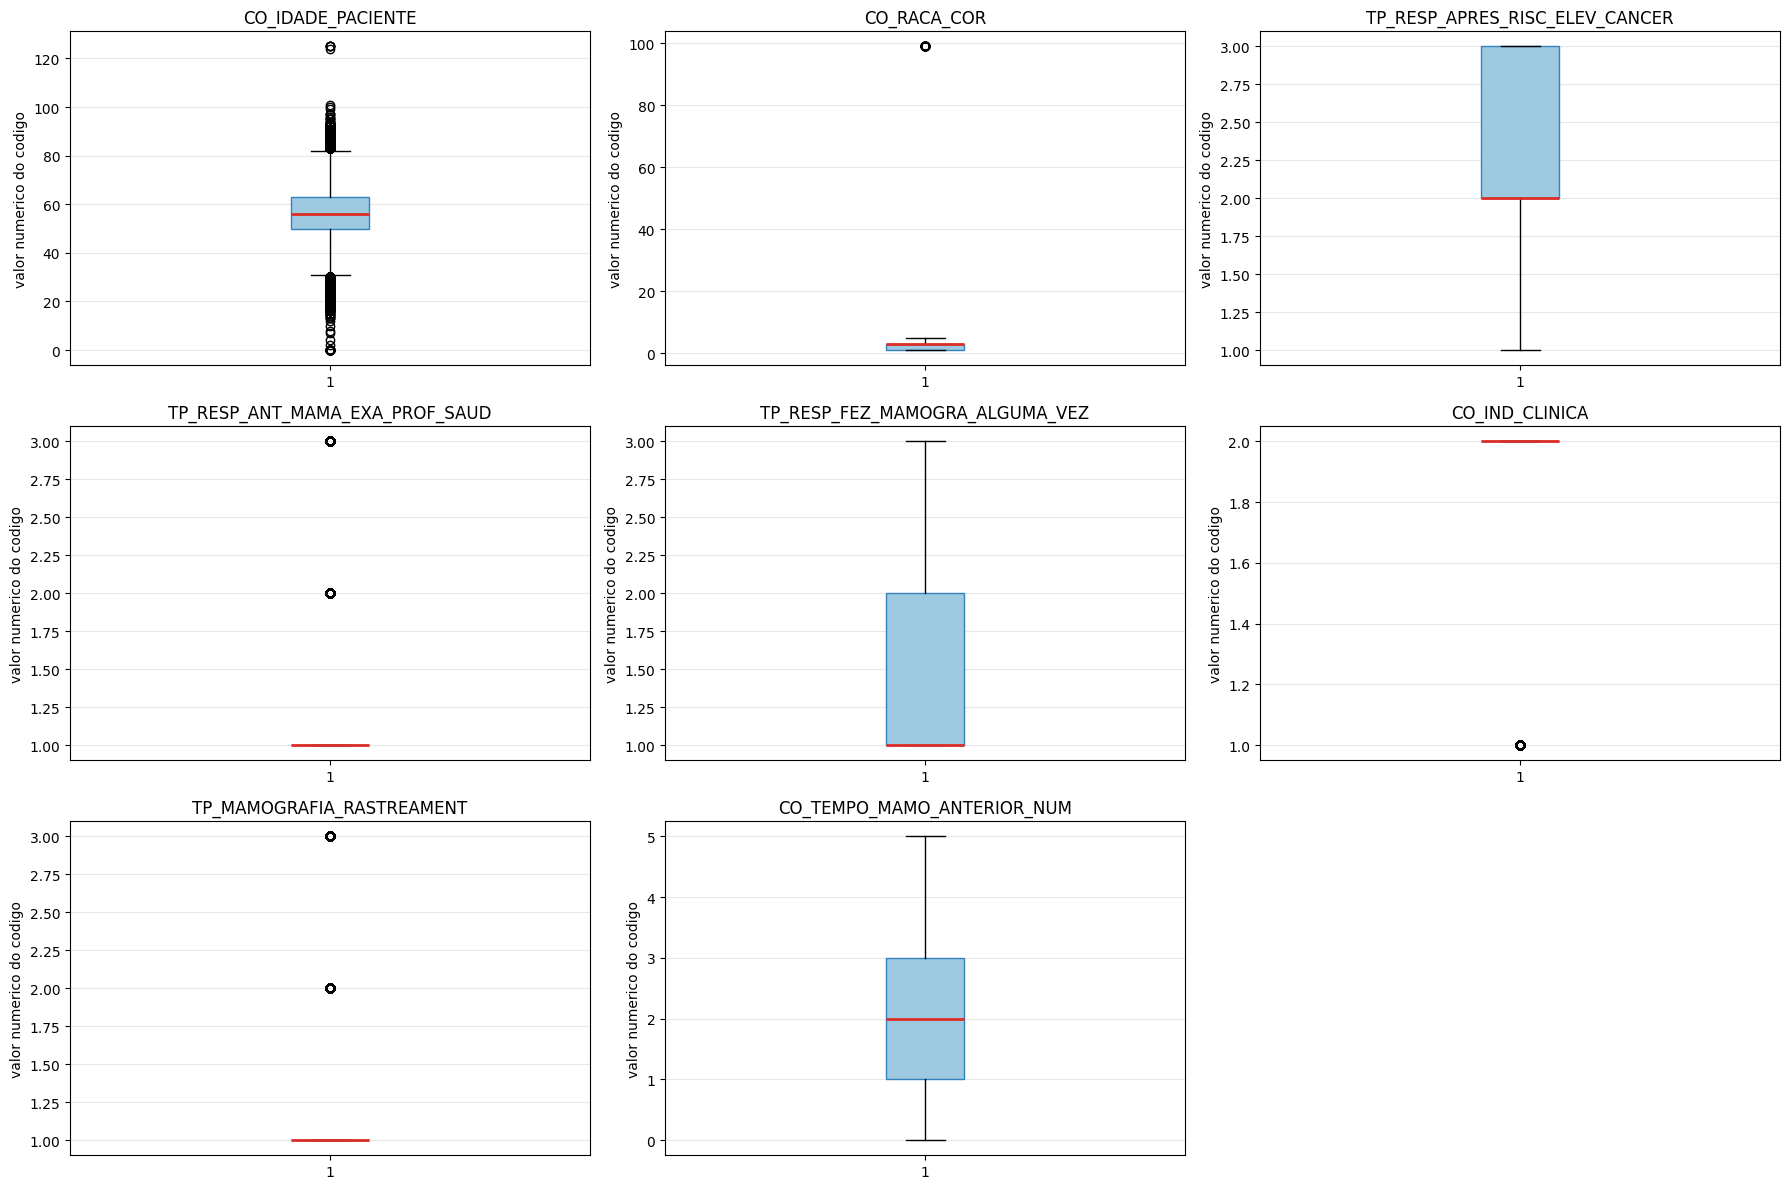

In [13]:
n_colunas = 3
n_linhas = -(-len(features_numericas_para_boxplot) // n_colunas)

fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(18, max(4, n_linhas * 4)))
axes = axes.flatten()

for ax, coluna in zip(axes, features_numericas_para_boxplot):
    ax.boxplot(
        features_boxplot[coluna].dropna(),
        vert=True,
        patch_artist=True,
        boxprops={'facecolor': '#9ecae1', 'edgecolor': '#3182bd'},
        medianprops={'color': '#de2d26', 'linewidth': 2},
    )
    ax.set_title(coluna)
    ax.set_ylabel('valor numerico do codigo')
    ax.grid(axis='y', alpha=0.3)

for ax in axes[len(features_numericas_para_boxplot):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
resumo_boxplot_outliers = []

for coluna in features_numericas_para_boxplot:
    serie = features_boxplot[coluna].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    qtd_outliers = ((serie < limite_inferior) | (serie > limite_superior)).sum()
    resumo_boxplot_outliers.append({
        'coluna': coluna,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'qtd_outliers_regra_iqr': int(qtd_outliers),
        'percentual_outliers': round(qtd_outliers / len(serie) * 100, 2),
    })

pd.DataFrame(resumo_boxplot_outliers).sort_values('percentual_outliers', ascending=False)

,coluna,q1,q3,iqr,limite_inferior,limite_superior,qtd_outliers_regra_iqr,percentual_outliers
3,TP_RESP_ANT_MAMA_EXA_PROF_SAUD,1.0,1.0,0.0,1.0,1.0,60318,22.55
6,TP_MAMOGRAFIA_RASTREAMENT,1.0,1.0,0.0,1.0,1.0,17194,6.71
5,CO_IND_CLINICA,2.0,2.0,0.0,2.0,2.0,11362,4.25
0,CO_IDADE_PACIENTE,50.0,63.0,13.0,30.5,82.5,2256,0.84
1,CO_RACA_COR,1.0,3.0,2.0,-2.0,6.0,42,0.02
2,TP_RESP_APRES_RISC_ELEV_CANCER,2.0,3.0,1.0,0.5,4.5,0,0.00
4,TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ,1.0,2.0,1.0,-0.5,3.5,0,0.00
7,CO_TEMPO_MAMO_ANTERIOR_NUM,1.0,3.0,2.0,-2.0,6.0,0,0.00


#### Item 7 - Separacao da base em treino e teste

Depois de definir a target e avaliar os outliers das features candidatas, vamos separar a base em treino e teste.

A separacao usa apenas `features_candidates` como entrada (`X`) e `TARGET_CANCER_MAMA_PROVAVEL` como saida (`y`). As colunas de resultado/laudo permanecem em `leakage_columns` e nao entram no `X`.

Como a target e desbalanceada, a divisao usa `stratify=y` para preservar aproximadamente a mesma proporcao de casos positivos e negativos nos conjuntos de treino e teste.


In [15]:
X = dados[features_candidates].copy()
y = dados[TARGET_COLUMN].copy()

TEST_SIZE = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

X_train: (213978, 9)
X_test: (53495, 9)
y_train: (213978,)
y_test: (53495,)


In [16]:
split_distribution = pd.concat(
    [
        y_train.value_counts(normalize=False).rename('treino_qtd'),
        (y_train.value_counts(normalize=True) * 100).round(2).rename('treino_percentual'),
        y_test.value_counts(normalize=False).rename('teste_qtd'),
        (y_test.value_counts(normalize=True) * 100).round(2).rename('teste_percentual'),
    ],
    axis=1,
).fillna(0)

split_distribution.index.name = TARGET_COLUMN
split_distribution

,treino_qtd,treino_percentual,teste_qtd,teste_percentual
TARGET_CANCER_MAMA_PROVAVEL,,,,
0,204902,95.76,51226,95.76
1,9076,4.24,2269,4.24


In [17]:
split_validation = {
    'features_usadas': features_candidates,
    'colunas_em_quarentena': quarantine_columns,
    'target': TARGET_COLUMN,
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
    'linhas_originais': len(dados),
    'linhas_treino': len(X_train),
    'linhas_teste': len(X_test),
    'linhas_preservadas': len(dados) == len(X_train) + len(X_test),
    'colunas_de_leakage_no_X': sorted(set(X.columns) & set(leakage_columns)),
    'colunas_de_quarentena_no_X': sorted(set(X.columns) & set(quarantine_columns)),
    'target_no_X': TARGET_COLUMN in X.columns,
}
split_validation

{'features_usadas': ['CO_IDADE_PACIENTE',
  'SG_SEXO',
  'CO_RACA_COR',
  'TP_RESP_APRES_RISC_ELEV_CANCER',
  'TP_RESP_ANT_MAMA_EXA_PROF_SAUD',
  'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ',
  'CO_IND_CLINICA',
  'TP_MAMOGRAFIA_RASTREAMENT',
  'CO_TEMPO_MAMO_ANTERIOR_NUM'],
 'colunas_em_quarentena': ['TP_MAMA_PELE_ESQ',
  'TP_MAMA_PELE_DIR',
  'TP_MAMA_ESQ',
  'TP_MAMA_DIR',
  'TP_LINFONODO_ESQ',
  'TP_LINFONODO_DIR'],
 'target': 'TARGET_CANCER_MAMA_PROVAVEL',
 'test_size': 0.2,
 'random_state': 42,
 'linhas_originais': 267473,
 'linhas_treino': 213978,
 'linhas_teste': 53495,
 'linhas_preservadas': True,
 'colunas_de_leakage_no_X': [],
 'colunas_de_quarentena_no_X': [],
 'target_no_X': False}

#### Item 8 - Aplicacao de cap na variavel de idade

A idade (`CO_IDADE_PACIENTE`) permanece relevante para risco e rastreamento de cancer de mama, mas nao deve seguir para modelagem como texto. Por isso, vamos criar duas versoes numericas nos splits de treino e teste:

- `CO_IDADE_PACIENTE_NUM`: idade convertida para valor numerico;
- `CO_IDADE_PACIENTE_CAP`: idade numerica limitada pelos percentis 1% e 99% calculados no conjunto de treino.

A coluna original `CO_IDADE_PACIENTE` sera removida de `X_train` e `X_test` antes do one-hot encoding e da exportacao final. Assim, as bases exportadas usam as versoes numericas da idade, mantendo `CO_IDADE_PACIENTE_CAP` para reduzir impacto de extremos e `CO_IDADE_PACIENTE_NUM` para rastreabilidade/modelagem alternativa.


In [18]:
idade_treino_original = pd.to_numeric(
    X_train['CO_IDADE_PACIENTE'].replace('', pd.NA),
    errors='coerce',
)
idade_teste_original = pd.to_numeric(
    X_test['CO_IDADE_PACIENTE'].replace('', pd.NA),
    errors='coerce',
)

idade_cap_min = idade_treino_original.quantile(0.01)
idade_cap_max = idade_treino_original.quantile(0.99)

X_train = X_train.copy()
X_test = X_test.copy()

X_train['CO_IDADE_PACIENTE_NUM'] = idade_treino_original
X_train['CO_IDADE_PACIENTE_CAP'] = idade_treino_original.clip(lower=idade_cap_min, upper=idade_cap_max)

X_test['CO_IDADE_PACIENTE_NUM'] = idade_teste_original
X_test['CO_IDADE_PACIENTE_CAP'] = idade_teste_original.clip(lower=idade_cap_min, upper=idade_cap_max)

X_train = X_train.drop(columns=['CO_IDADE_PACIENTE'])
X_test = X_test.drop(columns=['CO_IDADE_PACIENTE'])

# Mantem tambem no DataFrame completo para consultas exploratorias posteriores.
dados['CO_IDADE_PACIENTE_NUM'] = pd.to_numeric(
    dados['CO_IDADE_PACIENTE'].replace('', pd.NA),
    errors='coerce',
)
dados['CO_IDADE_PACIENTE_CAP'] = dados['CO_IDADE_PACIENTE_NUM'].clip(
    lower=idade_cap_min,
    upper=idade_cap_max,
)

print(f'Cap inferior idade calculado no treino: {idade_cap_min}')
print(f'Cap superior idade calculado no treino: {idade_cap_max}')

pd.DataFrame({
    'base': ['treino', 'teste'],
    'idade_num_nulos': [
        int(X_train['CO_IDADE_PACIENTE_NUM'].isna().sum()),
        int(X_test['CO_IDADE_PACIENTE_NUM'].isna().sum()),
    ],
    'idade_cap_min': [
        X_train['CO_IDADE_PACIENTE_CAP'].min(),
        X_test['CO_IDADE_PACIENTE_CAP'].min(),
    ],
    'idade_cap_max': [
        X_train['CO_IDADE_PACIENTE_CAP'].max(),
        X_test['CO_IDADE_PACIENTE_CAP'].max(),
    ],
    'qtd_colunas_x': [X_train.shape[1], X_test.shape[1]],
})


Cap inferior idade calculado no treino: 34.0
Cap superior idade calculado no treino: 78.0


,base,idade_num_nulos,idade_cap_min,idade_cap_max,qtd_colunas_x
0,treino,0,34,78,10
1,teste,0,34,78,10


In [19]:
idade_cap_resumo = pd.DataFrame([
    {
        'base': 'treino',
        'qtd_abaixo_cap': int((idade_treino_original < idade_cap_min).sum()),
        'qtd_acima_cap': int((idade_treino_original > idade_cap_max).sum()),
        'percentual_abaixo_cap': round((idade_treino_original < idade_cap_min).mean() * 100, 4),
        'percentual_acima_cap': round((idade_treino_original > idade_cap_max).mean() * 100, 4),
    },
    {
        'base': 'teste',
        'qtd_abaixo_cap': int((idade_teste_original < idade_cap_min).sum()),
        'qtd_acima_cap': int((idade_teste_original > idade_cap_max).sum()),
        'percentual_abaixo_cap': round((idade_teste_original < idade_cap_min).mean() * 100, 4),
        'percentual_acima_cap': round((idade_teste_original > idade_cap_max).mean() * 100, 4),
    },
])
idade_cap_resumo


,base,qtd_abaixo_cap,qtd_acima_cap,percentual_abaixo_cap,percentual_acima_cap
0,treino,1896,2016,0.8861,0.9422
1,teste,467,493,0.8730,0.9216


#### Item 9 - Colunas candidatas a One-Hot Encoding

As colunas abaixo sao categoricas de baixa cardinalidade, incluindo `SG_SEXO`, e devem ser tratadas com one-hot encoding antes de algoritmos classificatorios que esperam entrada numerica.

Depois do one-hot encoding, cada categoria vira uma coluna binaria com valores `0` ou `1`. Por isso, a interpretacao de outlier por boxplot/IQR deixa de ser adequada para essas variaveis: uma coluna binaria nao mede distancia, intensidade ou grandeza continua; ela apenas indica ausencia ou presenca de uma categoria. Em uma variavel dummy, valores validos sao somente `0` e `1`, entao nao ha outlier numerico no sentido classico.

O que pode existir sao **categorias raras**. Por isso, o resumo abaixo traz `menor_frequencia` e `menor_percentual`:

- `menor_frequencia`: quantidade absoluta de registros da categoria menos frequente daquela coluna;
- `menor_percentual`: percentual dessa categoria em relacao ao total da base.

Essas metricas ajudam a identificar categorias pouco representadas, que podem gerar colunas one-hot muito esparsas e instaveis para o modelo. Quando uma categoria tiver frequencia muito baixa, a decisao pode ser agrupar em `Outros`, manter por relevancia clinica, ou avaliar o impacto durante a validacao do modelo.

A tabela gerada em seguida detalha cada coluna, cada valor observado, o significado usado no projeto, a frequencia absoluta, o percentual e o nome sugerido da dummy resultante.

As exclusoes abaixo se referem a **classes/categorias dentro das colunas pre-exame**, nao a remocao das colunas originais antes do encoding. As colunas continuam sendo usadas no one-hot para as demais categorias validas; apenas as classes listadas nao geram uma dummy propria.

Classes que nao serao transformadas em dummies:

- `CO_RACA_COR=99`: codigo de raca/cor ignorada ou sem informacao. Criar uma dummy para essa classe poderia fazer o modelo aprender padroes associados a ausencia de preenchimento, e nao a uma caracteristica clinica ou demografica informativa.
- `TP_MAMOGRAFIA_RASTREAMENT=<NA>`: valor ausente/nao aplicavel, geralmente associado a exames que nao sao de rastreamento. Como nao representa uma categoria clinica positiva da pergunta de rastreamento, nao sera codificado como dummy.

Na matriz final, esses registros permanecem representados por zeros nas dummies da respectiva coluna.


In [20]:
one_hot_encoded_columns = [
    'SG_SEXO',
    'CO_RACA_COR',
    'TP_RESP_APRES_RISC_ELEV_CANCER',
    'TP_RESP_ANT_MAMA_EXA_PROF_SAUD',
    'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ',
    'CO_IND_CLINICA',
    'TP_MAMOGRAFIA_RASTREAMENT',
]

one_hot_encoded_columns = [
    coluna for coluna in one_hot_encoded_columns
    if coluna in features_candidates and coluna in dados.columns
]

one_hot_values_not_encoded = {
    'CO_RACA_COR': {'99'},
    'TP_MAMOGRAFIA_RASTREAMENT': {'<NA>'},
}

one_hot_values_not_encoded_reasons = {
    ('CO_RACA_COR', '99'): 'classe ignorada/sem informacao; nao representa uma categoria demografica informativa',
    ('TP_MAMOGRAFIA_RASTREAMENT', '<NA>'): 'ausente ou nao aplicavel; geralmente nao corresponde a uma categoria de rastreamento informada',
}

significados_one_hot = {
    'SG_SEXO': {'F': 'Feminino', 'M': 'Masculino', 'I': 'Ignorado/indeterminado'},
    'CO_RACA_COR': {
        '01': 'Branca',
        '02': 'Preta',
        '03': 'Parda',
        '04': 'Amarela',
        '05': 'Indigena',
        '99': 'Sem informacao/ignorado',
    },
    'TP_RESP_APRES_RISC_ELEV_CANCER': {'01': 'Sim', '02': 'Nao', '03': 'Nao sabe'},
    'TP_RESP_ANT_MAMA_EXA_PROF_SAUD': {'01': 'Sim', '02': 'Nao', '03': 'Nao sabe'},
    'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ': {'01': 'Sim', '02': 'Nao', '03': 'Nao sabe'},
    'CO_IND_CLINICA': {'01': 'Mamografia diagnostica', '02': 'Mamografia de rastreamento'},
    'TP_MAMOGRAFIA_RASTREAMENT': {
        '<NA>': 'nao se aplica/sem preenchimento; geralmente exame diagnostico',
        '01': 'Populacao-alvo',
        '02': 'Populacao de risco elevado por historia familiar',
        '03': 'Paciente ja tratado de cancer de mama',
    },
    'TP_MAMA_PELE_ESQ': {'<NA>': 'nao se aplica/sem preenchimento', '01': 'Normal', '02': 'Alterada'},
    'TP_MAMA_PELE_DIR': {'<NA>': 'nao se aplica/sem preenchimento', '01': 'Normal', '02': 'Alterada'},
    'TP_MAMA_ESQ': {
        '<NA>': 'nao se aplica/sem preenchimento',
        '01': 'Densa',
        '02': 'Adiposa',
        '03': 'Predominantemente densa',
        '04': 'Predominantemente adiposa',
        '05': 'Parenquima deslocado anteriormente pelo implante',
        '06': 'Mama reconstruida',
    },
    'TP_MAMA_DIR': {
        '<NA>': 'nao se aplica/sem preenchimento',
        '01': 'Densa',
        '02': 'Adiposa',
        '03': 'Predominantemente densa',
        '04': 'Predominantemente adiposa',
        '05': 'Parenquima deslocado anteriormente pelo implante',
        '06': 'Mama reconstruida',
    },
    'TP_LINFONODO_ESQ': {'<NA>': 'nao se aplica/sem preenchimento', '01': 'Normal', '02': 'Alterado', '03': 'Nao visualizado'},
    'TP_LINFONODO_DIR': {'<NA>': 'nao se aplica/sem preenchimento', '01': 'Normal', '02': 'Alterado', '03': 'Nao visualizado'},
}

linhas_one_hot = []
for coluna in one_hot_encoded_columns:
    serie = dados[coluna].replace('', pd.NA).astype('string')
    frequencias = serie.value_counts(dropna=False).sort_index()
    valores_nao_codificados = one_hot_values_not_encoded.get(coluna, set())

    for valor, frequencia in frequencias.items():
        valor_chave = '<NA>' if pd.isna(valor) else str(valor)
        codificar_one_hot = valor_chave not in valores_nao_codificados
        linhas_one_hot.append({
            'coluna': coluna,
            'valor': valor_chave,
            'significado': significados_one_hot.get(coluna, {}).get(valor_chave, 'significado nao mapeado'),
            'frequencia': int(frequencia),
            'percentual': round(frequencia / len(dados) * 100, 4),
            'codificar_one_hot': codificar_one_hot,
            'motivo_exclusao': one_hot_values_not_encoded_reasons.get((coluna, valor_chave), pd.NA),
            'dummy_resultante': f"{coluna}_{valor_chave}" if codificar_one_hot else pd.NA,
        })

one_hot_value_details = pd.DataFrame(linhas_one_hot)
one_hot_classes_excluidas = one_hot_value_details.loc[
    ~one_hot_value_details['codificar_one_hot'],
    ['coluna', 'valor', 'significado', 'frequencia', 'percentual', 'motivo_exclusao'],
].reset_index(drop=True)

one_hot_value_details


,coluna,valor,significado,frequencia,percentual,codificar_one_hot,motivo_exclusao,dummy_resultante
0,SG_SEXO,F,Feminino,266775,99.7390,True,NaN,SG_SEXO_F
1,SG_SEXO,I,Ignorado/indeterminado,1,0.0004,True,NaN,SG_SEXO_I
2,SG_SEXO,M,Masculino,697,0.2606,True,NaN,SG_SEXO_M
3,CO_RACA_COR,01,Branca,99343,37.1413,True,NaN,CO_RACA_COR_01
4,CO_RACA_COR,02,Preta,33115,12.3807,True,NaN,CO_RACA_COR_02
5,CO_RACA_COR,03,Parda,104803,39.1826,True,NaN,CO_RACA_COR_03
6,CO_RACA_COR,04,Amarela,30136,11.2669,True,NaN,CO_RACA_COR_04
7,CO_RACA_COR,05,Indigena,34,0.0127,True,NaN,CO_RACA_COR_05
8,CO_RACA_COR,99,Sem informacao/ignorado,42,0.0157,False,classe ignorada/sem informacao; nao representa...,NaN
9,TP_RESP_APRES_RISC_ELEV_CANCER,01,Sim,45465,16.9980,True,NaN,TP_RESP_APRES_RISC_ELEV_CANCER_01


In [21]:
one_hot_classes_excluidas


,coluna,valor,significado,frequencia,percentual,motivo_exclusao
0,CO_RACA_COR,99,Sem informacao/ignorado,42,0.0157,classe ignorada/sem informacao; nao representa...
1,TP_MAMOGRAFIA_RASTREAMENT,<NA>,nao se aplica/sem preenchimento; geralmente ex...,11362,4.2479,ausente ou nao aplicavel; geralmente nao corre...


#### Item 10 - Aplicacao do One-Hot Encoding nas features candidatas

O encoding sera ajustado no conjunto de treino e replicado no conjunto de teste com as mesmas colunas. As categorias configuradas em `one_hot_values_not_encoded` nao geram dummy propria.


In [22]:
def preparar_serie_para_one_hot(serie, coluna):
    valores_nao_codificados = one_hot_values_not_encoded.get(coluna, set())
    serie_preparada = serie.replace('', pd.NA).astype('string').fillna('<NA>')
    return serie_preparada.mask(serie_preparada.isin(valores_nao_codificados), pd.NA)


def aplicar_one_hot_sem_valores_excluidos(df, colunas, dummy_columns=None):
    df_encoded = df.copy()
    dummies_por_coluna = []

    for coluna in colunas:
        serie_preparada = preparar_serie_para_one_hot(df_encoded[coluna], coluna)
        dummies = pd.get_dummies(
            serie_preparada,
            prefix=coluna,
            prefix_sep='_',
            dtype='int8',
        )
        dummies_por_coluna.append(dummies)

    df_encoded = df_encoded.drop(columns=colunas)

    if dummies_por_coluna:
        dummies_todas = pd.concat(dummies_por_coluna, axis=1)
    else:
        dummies_todas = pd.DataFrame(index=df_encoded.index)

    if dummy_columns is None:
        dummy_columns = dummies_todas.columns.tolist()
    else:
        dummies_todas = dummies_todas.reindex(columns=dummy_columns, fill_value=0)

    df_encoded = pd.concat([df_encoded, dummies_todas], axis=1)
    return df_encoded, dummy_columns


X_train_encoded, one_hot_dummy_columns = aplicar_one_hot_sem_valores_excluidos(
    X_train,
    one_hot_encoded_columns,
)
X_test_encoded, _ = aplicar_one_hot_sem_valores_excluidos(
    X_test,
    one_hot_encoded_columns,
    dummy_columns=one_hot_dummy_columns,
)

one_hot_encoding_validation = {
    'colunas_one_hot_origem': one_hot_encoded_columns,
    'qtd_dummies_criadas': len(one_hot_dummy_columns),
    'dummies_criadas': one_hot_dummy_columns,
    'dummies_excluidas': sorted(
        f'{coluna}_{valor}'
        for coluna, valores in one_hot_values_not_encoded.items()
        for valor in valores
    ),
    'shape_treino_original': X_train.shape,
    'shape_teste_original': X_test.shape,
    'shape_treino_encoded': X_train_encoded.shape,
    'shape_teste_encoded': X_test_encoded.shape,
    'mesmas_colunas_treino_teste': X_train_encoded.columns.equals(X_test_encoded.columns),
    'colunas_categoricas_originais_removidas': not any(
        coluna in X_train_encoded.columns for coluna in one_hot_encoded_columns
    ),
}

one_hot_encoding_validation


{'colunas_one_hot_origem': ['SG_SEXO',
  'CO_RACA_COR',
  'TP_RESP_APRES_RISC_ELEV_CANCER',
  'TP_RESP_ANT_MAMA_EXA_PROF_SAUD',
  'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ',
  'CO_IND_CLINICA',
  'TP_MAMOGRAFIA_RASTREAMENT'],
 'qtd_dummies_criadas': 22,
 'dummies_criadas': ['SG_SEXO_F',
  'SG_SEXO_I',
  'SG_SEXO_M',
  'CO_RACA_COR_01',
  'CO_RACA_COR_02',
  'CO_RACA_COR_03',
  'CO_RACA_COR_04',
  'CO_RACA_COR_05',
  'TP_RESP_APRES_RISC_ELEV_CANCER_01',
  'TP_RESP_APRES_RISC_ELEV_CANCER_02',
  'TP_RESP_APRES_RISC_ELEV_CANCER_03',
  'TP_RESP_ANT_MAMA_EXA_PROF_SAUD_01',
  'TP_RESP_ANT_MAMA_EXA_PROF_SAUD_02',
  'TP_RESP_ANT_MAMA_EXA_PROF_SAUD_03',
  'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ_01',
  'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ_02',
  'TP_RESP_FEZ_MAMOGRA_ALGUMA_VEZ_03',
  'CO_IND_CLINICA_01',
  'CO_IND_CLINICA_02',
  'TP_MAMOGRAFIA_RASTREAMENT_01',
  'TP_MAMOGRAFIA_RASTREAMENT_02',
  'TP_MAMOGRAFIA_RASTREAMENT_03'],
 'dummies_excluidas': ['CO_RACA_COR_99', 'TP_MAMOGRAFIA_RASTREAMENT_<NA>'],
 'shape_treino_o

#### Item 11 - Exportacao dos dados finais em Parquet

Nesta etapa, as bases finais sao exportadas em `bases/`, com pastas separadas para treino e teste. Cada pasta contem tres arquivos Parquet:

- `x.parquet`: features originais do split, antes do one-hot encoding;
- `x_encoded.parquet`: features do split depois do one-hot encoding;
- `y.parquet`: variavel alvo do split.

Essa separacao preserva a rastreabilidade entre a base antes do encoding, a matriz pronta para modelagem e a target correspondente.


In [23]:
pasta_treino = Path('bases/treino')
pasta_teste = Path('bases/teste')
pasta_treino.mkdir(parents=True, exist_ok=True)
pasta_teste.mkdir(parents=True, exist_ok=True)

arquivos_exportacao = {
    'x_treino': pasta_treino / 'x.parquet',
    'x_treino_encoded': pasta_treino / 'x_encoded.parquet',
    'y_treino': pasta_treino / 'y.parquet',
    'x_teste': pasta_teste / 'x.parquet',
    'x_teste_encoded': pasta_teste / 'x_encoded.parquet',
    'y_teste': pasta_teste / 'y.parquet',
}

X_train.reset_index(drop=True).to_parquet(arquivos_exportacao['x_treino'], index=False)
X_train_encoded.reset_index(drop=True).to_parquet(arquivos_exportacao['x_treino_encoded'], index=False)
y_train.reset_index(drop=True).to_frame(TARGET_COLUMN).to_parquet(arquivos_exportacao['y_treino'], index=False)

X_test.reset_index(drop=True).to_parquet(arquivos_exportacao['x_teste'], index=False)
X_test_encoded.reset_index(drop=True).to_parquet(arquivos_exportacao['x_teste_encoded'], index=False)
y_test.reset_index(drop=True).to_frame(TARGET_COLUMN).to_parquet(arquivos_exportacao['y_teste'], index=False)

exportacao_final_validacao = {
    'arquivos_exportados': {nome: str(caminho.resolve()) for nome, caminho in arquivos_exportacao.items()},
    'shape_x_treino': X_train.shape,
    'shape_x_treino_encoded': X_train_encoded.shape,
    'shape_y_treino': y_train.shape,
    'shape_x_teste': X_test.shape,
    'shape_x_teste_encoded': X_test_encoded.shape,
    'shape_y_teste': y_test.shape,
    'mesmas_linhas_treino': len(X_train) == len(X_train_encoded) == len(y_train),
    'mesmas_linhas_teste': len(X_test) == len(X_test_encoded) == len(y_test),
    'mesmas_colunas_encoded_treino_teste': X_train_encoded.columns.equals(X_test_encoded.columns),
    'arquivos_criados': all(caminho.exists() for caminho in arquivos_exportacao.values()),
}

exportacao_final_validacao


{'arquivos_exportados': {'x_treino': '/Users/igorcarletti/Development/workspace/trabalho2/bases/treino/x.parquet',
  'x_treino_encoded': '/Users/igorcarletti/Development/workspace/trabalho2/bases/treino/x_encoded.parquet',
  'y_treino': '/Users/igorcarletti/Development/workspace/trabalho2/bases/treino/y.parquet',
  'x_teste': '/Users/igorcarletti/Development/workspace/trabalho2/bases/teste/x.parquet',
  'x_teste_encoded': '/Users/igorcarletti/Development/workspace/trabalho2/bases/teste/x_encoded.parquet',
  'y_teste': '/Users/igorcarletti/Development/workspace/trabalho2/bases/teste/y.parquet'},
 'shape_x_treino': (213978, 10),
 'shape_x_treino_encoded': (213978, 25),
 'shape_y_treino': (213978,),
 'shape_x_teste': (53495, 10),
 'shape_x_teste_encoded': (53495, 25),
 'shape_y_teste': (53495,),
 'mesmas_linhas_treino': True,
 'mesmas_linhas_teste': True,
 'mesmas_colunas_encoded_treino_teste': True,
 'arquivos_criados': True}

---

## Resultado da Parte 2

Ao executar este notebook, ficam definidos os principais objetos para preparacao de algoritmos classificatorios:

```python
features_candidates
leakage_columns
high_cardinality
one_hot_encoded_columns
one_hot_values_not_encoded
one_hot_classes_excluidas
TARGET_COLUMN
X_train, X_test, y_train, y_test
X_train_encoded, X_test_encoded
```

Resultado validado:

- `X_train`: 213978 linhas e 10 colunas.
- `X_train_encoded`: 213978 linhas e 25 colunas.
- `y_train`: 213978 linhas e 1 coluna.
- `X_test`: 53495 linhas e 10 colunas.
- `X_test_encoded`: 53495 linhas e 25 colunas.
- `y_test`: 53495 linhas e 1 coluna.
- As bases de treino e teste usam `CO_IDADE_PACIENTE_NUM` e `CO_IDADE_PACIENTE_CAP` no lugar de `CO_IDADE_PACIENTE` texto.
- A coluna `CO_TEMPO_MAMO_ANTERIOR_NUM` vem da base tratada e permanece como feature numerica de historico mamografico.
- As matrizes encoded de treino e teste possuem o mesmo schema.
- As classes excluidas do one-hot nao geram dummies proprias.

Arquivos exportados:

```text
bases/treino/x.parquet
bases/treino/x_encoded.parquet
bases/treino/y.parquet
bases/teste/x.parquet
bases/teste/x_encoded.parquet
bases/teste/y.parquet
```

Esses arquivos separam as features originais, as features codificadas e a target de cada split, servindo como entrada para as proximas etapas de modelagem classificatoria.
